In [1]:
import pandas as pd

df = pd.read_csv('../data/raw/inaug_speeches.csv', encoding='latin1')
print("Données chargées avec succès !")


Données chargées avec succès !


In [2]:
df.head(3)

,Unnamed: 0,Name,Inaugural Address,Date,text
0,4,George Washington,First Inaugural Address,"Thursday, April 30, 1789",Fellow-Citizens of the Senate and o...
1,5,George Washington,Second Inaugural Address,"Monday, March 4, 1793",Fellow Citizens: I AM again cal...
2,6,John Adams,Inaugural Address,"Saturday, March 4, 1797","WHEN it was first perceived, in ..."


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Unnamed: 0         58 non-null     int64
 1   Name               58 non-null     str  
 2   Inaugural Address  58 non-null     str  
 3   Date               58 non-null     str  
 4   text               58 non-null     str  
dtypes: int64(1), str(4)
memory usage: 2.4 KB


In [4]:
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

In [5]:
#supprimer les lignes vides
df = df.dropna(subset='text')

# 2. Initialisation des outils NLP
lemmatiseur = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

In [6]:
def preprocess_text(text):
    # Enlever les sauts de ligne et mettre en minuscules
    text = text.strip().lower().replace('\n', ' ')
    
    # Supprimer la ponctuation et les chiffres
    text = text.translate(str.maketrans('', '', string.punctuation + string.digits))
    
    # Tokenisation (découpage en mots)
    tokens = word_tokenize(text)
    
    # Filtrage des stop words et Lemmatisation
    cleaned_tokens = [
        lemmatiseur.lemmatize(word) 
        for word in tokens 
        if word not in stop_words and len(word) > 2 # On ignore les mots de moins de 3 lettres
    ]
    
    # On retourne une liste de mots nettoyés
    return cleaned_tokens

# 3. Application du traitement sur l'ensemble du dataset
print("Lancement du prétraitement des discours (cette opération peut prendre quelques secondes)...")
df['tokens_nettoyes'] = df['text'].apply(preprocess_text)

# Phrases pour mle tfidf
df['texte_nettoye'] = df['tokens_nettoyes'].apply(lambda x: ' '.join(x))

print("Resultat de la premiere ligne ")
print(df[['text', 'tokens_nettoyes']].head(1))

print("Resultat de la deuxieme")
print(df[['text', 'tokens_nettoyes']].head(2))

Lancement du prétraitement des discours (cette opération peut prendre quelques secondes)...
Resultat de la premiere ligne 
                                                text  \
0             Fellow-Citizens of the Senate and o...   

                                     tokens_nettoyes  
0  [fellowcitizens, senate, house, representative...  
Resultat de la deuxieme
                                                text  \
0             Fellow-Citizens of the Senate and o...   
1              Fellow Citizens:    I AM again cal...   

                                     tokens_nettoyes  
0  [fellowcitizens, senate, house, representative...  
1  [fellow, citizen, called, upon, voice, country...  


In [7]:
df.to_csv('../data/processed/inaug_speeches_nettoye.csv', index=False, encoding='utf-8')

In [8]:
from textblob import TextBlob

In [9]:
import pandas as pd
from textblob import TextBlob

#fonctions pour obtenir la polarite et la subjectivite
def obtenir_polarite(texte):
    return TextBlob(str(texte)).sentiment.polarity

def obtenir_subjectivite(texte):
    return TextBlob(str(texte)).sentiment.subjectivity

#on fait l analyse sur les jeux de donnees
print("Calcul des scores de sentiment en cours...")
df['polarite'] = df['text'].apply(obtenir_polarite)
df['subjectivite'] = df['text'].apply(obtenir_subjectivite)

print(df['polarite'].head(1))
print(df['subjectivite'].head(1))

# on evalue maintenant les tonalites
def evaluer_tonalite(score):
    if score > 0.15:
        return 'discours positif'
    elif score < 0.05:
        return 'discours negatif'
    else:
        return 'discours est neutre'

df['tonalite'] = df['polarite'].apply(evaluer_tonalite)

print("Analyse terminée avec succès !")

# Aperçu du résultat avec les colonnes clés (par exemple le Président, l'Année et les scores)
# Adaptez 'President' et 'Year' selon les vrais noms de vos colonnes Kaggle

print(df.head(5))

Calcul des scores de sentiment en cours...
0    0.2041
Name: polarite, dtype: float64
0    0.429194
Name: subjectivite, dtype: float64
Analyse terminée avec succès !
   Unnamed: 0               Name         Inaugural Address  \
0           4  George Washington   First Inaugural Address   
1           5  George Washington  Second Inaugural Address   
2           6         John Adams         Inaugural Address   
3           7   Thomas Jefferson   First Inaugural Address   
4           8   Thomas Jefferson  Second Inaugural Address   

                       Date  \
0  Thursday, April 30, 1789   
1     Monday, March 4, 1793   
2   Saturday, March 4, 1797   
3  Wednesday, March 4, 1801   
4     Monday, March 4, 1805   

                                                text  \
0             Fellow-Citizens of the Senate and o...   
1              Fellow Citizens:    I AM again cal...   
2                WHEN it was first perceived, in ...   
3              Friends and Fellow-Citizens:    CA.

In [10]:
#enregistrer juste les trois colonnes apres pour la visualisations en sortie
colonnes_a_garder = ['Unnamed: 0', 'polarite', 'subjectivite','tonalite']
df.to_csv('../data/processed/inaug_speeches_nettoye_tonetsent.csv', columns=colonnes_a_garder, index=False, encoding='utf-8')

PREPARATION DU CALCUL TD IDF

In [11]:
from collections import Counter

#on met tous les discours dans une liste
tout_le_texte = " ".join(df['texte_nettoye'].astype(str))
print(tout_le_texte);



fellowcitizens senate house representative among vicissitude incident life event could filled greater anxiety notification transmitted order received day present month one hand summoned country whose voice never hear veneration love retreat chosen fondest predilection flattering hope immutable decision asylum declining yearsua retreat rendered every day necessary well dear addition habit inclination frequent interruption health gradual waste committed time hand magnitude difficulty trust voice country called sufficient awaken wisest experienced citizen distrustful scrutiny qualification could overwhelm despondence one inheriting inferior endowment nature unpracticed duty civil administration ought peculiarly conscious deficiency conflict emotion dare aver faithful study collect duty appreciation every circumstance might affected dare hope executing task much swayed grateful remembrance former instance affectionate sensibility transcendent proof confidence fellowcitizens thence little c

In [12]:
# on decoupe la liste pour compter chaque mot
tous_les_mots = tout_le_texte.split()

#on compte chaque occurrence des mots
compteur_mots = Counter(tous_les_mots)

# on affiche les 3 mots qui revienent le plus souvent
top_10_frequence = compteur_mots.most_common(10)

print("les mots les plus frequents de notre documents sont")
for mot, nb in top_10_frequence:
    print(f"{mot:<10} : {nb} fois")

les mots les plus frequents de notre documents sont
government : 620 fois
people     : 616 fois
nation     : 505 fois
state      : 440 fois
upon       : 373 fois
must       : 365 fois
country    : 350 fois
great      : 338 fois
may        : 337 fois
power      : 334 fois


On peut donc estimer que ce sont les mots qui auront moins d importance dans les documents

In [13]:
#on passe au calcul tf-idf

In [14]:
import math
import collections
import pandas as pd

#chargement des données nettoyes
df = pd.read_csv('../data/processed/inaug_speeches_nettoye.csv', encoding='latin1')

# S'assurer que les données sont bien des chaînes de caractères et nettoyer les espaces
corpus = df['texte_nettoye'].fillna("").astype(str).tolist()
docs_mots = [doc.split() for doc in corpus]
N = len(corpus)  # Nombre total de discours

print(corpus)



['fellowcitizens senate house representative among vicissitude incident life event could filled greater anxiety notification transmitted order received day present month one hand summoned country whose voice never hear veneration love retreat chosen fondest predilection flattering hope immutable decision asylum declining yearsua retreat rendered every day necessary well dear addition habit inclination frequent interruption health gradual waste committed time hand magnitude difficulty trust voice country called sufficient awaken wisest experienced citizen distrustful scrutiny qualification could overwhelm despondence one inheriting inferior endowment nature unpracticed duty civil administration ought peculiarly conscious deficiency conflict emotion dare aver faithful study collect duty appreciation every circumstance might affected dare hope executing task much swayed grateful remembrance former instance affectionate sensibility transcendent proof confidence fellowcitizens thence little

In [15]:
# --- LA CORRECTION EST ICI : On crée et on remplit df_counts ---
df_counts = collections.Counter()
for mots in docs_mots:
    df_counts.update(set(mots))  # On compte 1 par document contenant le mot
# --------------------------------------------------------------

# Maintenant cette ligne fonctionne sans erreur !
tous_les_mots_uniques = set(df_counts.keys())

# 2. Calcul de l'IDF BRUT (Sans aucun filtre sur le pourcentage d'apparition)
idf_brut = {}
for mot in tous_les_mots_uniques:
    nb_docs_avec_mot = df_counts[mot]
    # Formule mathématique standard du TF-IDF
    idf_brut[mot] = math.log((1 + N) / (1 + nb_docs_avec_mot)) + 1

# 3. Calcul du TF-IDF pour chaque discours
mots_cles_bruts = []
mots_les_moins_cles_bruts = []

for mots in docs_mots:
    if not mots:
        mots_cles_bruts.append("Aucun")
        mots_les_moins_cles_bruts.append("Aucun")
        continue
        
    tf = collections.Counter(mots)
    total_mots = len(mots)
    
    scores_tfidf = {}
    for mot in tf:
        scores_tfidf[mot] = (tf[mot] / total_mots) * idf_brut[mot]
            
    # Tri des mots du plus significatif au moins significatif
    mots_tries = sorted(scores_tfidf.items(), key=lambda x: x[1], reverse=True)
    
    # Top 3 (Plus hauts scores)
    top_3 = mots_tries[:3]
    mots_cles_bruts.append(", ".join([mot for mot, score in top_3]))
    
    # Flop 3 (Plus bas scores)
    flop_3 = mots_tries[-3:]
    mots_les_moins_cles_bruts.append(", ".join([mot for mot, score in flop_3]))

# Mise à jour de votre DataFrame
df['mots_cles_tfidf'] = mots_cles_bruts
df['mots_les_moins_cles_tfidf'] = mots_les_moins_cles_bruts

# Affichage du résultat
print("--- ANALYSE TF-IDF BRUTE SANS AUCUN FILTRE ---")
print(df[['mots_cles_tfidf', 'mots_les_moins_cles_tfidf']].head(5))

--- ANALYSE TF-IDF BRUTE SANS AUCUN FILTRE ---
                         mots_cles_tfidf    mots_les_moins_cles_tfidf
0              every, government, public           would, time, world
1           arrive, upbraiding, violated  country, government, people
2             people, nation, government               new, hope, one
3  government, principle, fellowcitizens          life, great, people
4          public, state, fellowcitizens             free, one, great


In [16]:
#FAISONS UNE VERIFICATION EN APPLIQUANT MAINTENANT UN FILTRE

In [17]:
# 1. Calcul de l'IDF AVEC FILTRE (max 85% de présence)
idf_filtre = {}
seuil_max = 0.85

for mot in tous_les_mots_uniques:
    nb_docs_avec_mot = df_counts[mot]
    proportion_presence = nb_docs_avec_mot / N
    
    # L'ASTUCE : Si le mot est trop commun, on l'éjecte du dictionnaire
    if proportion_presence > seuil_max:
        continue
        
    # Formule standard pour les mots qui ont survécu
    idf_filtre[mot] = math.log((1 + N) / (1 + nb_docs_avec_mot)) + 1

# 2. Calcul du TF-IDF filtré pour chaque discours
mots_cles_filtres = []
mots_les_moins_cles_filtres = []

for mots in docs_mots:
    if not mots:
        mots_cles_filtres.append("Aucun")
        mots_les_moins_cles_filtres.append("Aucun")
        continue
        
    tf = collections.Counter(mots)
    total_mots = len(mots)
    
    scores_tfidf = {}
    for mot in tf:
        # On calcule le score UNIQUEMENT si le mot est dans notre dictionnaire filtré
        if mot in idf_filtre:
            scores_tfidf[mot] = (tf[mot] / total_mots) * idf_filtre[mot]
            
    # Tri des mots valides
    mots_tries = sorted(scores_tfidf.items(), key=lambda x: x[1], reverse=True)
    
    # Top 3 (Plus hauts scores)
    top_3 = mots_tries[:3]
    mots_cles_filtres.append(", ".join([mot for mot, score in top_3]))
    
    # Flop 3 (Plus bas scores)
    flop_3 = mots_tries[-3:]
    mots_les_moins_cles_filtres.append(", ".join([mot for mot, score in flop_3]))

# Mise à jour du DataFrame
df['mots_cles_tfidf'] = mots_cles_filtres
df['mots_les_moins_cles_tfidf'] = mots_les_moins_cles_filtres

# Affichage du résultat
print("--- ANALYSE TF-IDF AVEC FILTRE À 85% ---")
print(df[['mots_cles_tfidf', 'mots_les_moins_cles_tfidf']].head(5))

--- ANALYSE TF-IDF AVEC FILTRE À 85% ---
                    mots_cles_tfidf mots_les_moins_cles_tfidf
0   public, immutable, providential            men, life, new
1      arrive, upbraiding, violated     upon, united, citizen
2      legislature, pleasing, state         future, new, hope
3  principle, fellowcitizens, error        upon, future, life
4     public, state, fellowcitizens            men, new, free


In [18]:
#ESSAYER AVEC UN FILTRE INCLUSIF EN ACCORD MOINS D'IMPORTANCE AUX MOTS REPETITIFS
import math
import collections

# 1. Calcul de l'IDF mathématique pur (SANS AUCUN FILTRE D'EXCLUSION)
idf_pure = {}
for mot in tous_les_mots_uniques:
    nb_docs_avec_mot = df_counts[mot]
    
    # Formule mathématique qui donne un score de ZERO si le mot est dans TOUS les discours
    # Si le mot est présent partout (nb_docs == N), N/nb_docs = 1, et log(1) = 0.
    idf_pure[mot] = math.log(N / nb_docs_avec_mot)

# 2. Calcul du TF-IDF pour chaque discours
mots_cles_reels = []
mots_les_moins_cles_reels = []

for mots in docs_mots:
    if not mots:
        mots_cles_reels.append("Aucun")
        mots_les_moins_cles_reels.append("Aucun")
        continue
        
    tf = collections.Counter(mots)
    total_mots = len(mots)
    
    scores_tfidf = {}
    for mot in tf:
        scores_tfidf[mot] = (tf[mot] / total_mots) * idf_pure[mot]
            
    # Tri des mots du plus grand score au plus faible
    mots_tries = sorted(scores_tfidf.items(), key=lambda x: x[1], reverse=True)
    
    # Top 3 (Plus hauts scores)
    top_3 = mots_tries[:3]
    mots_cles_reels.append(", ".join([mot for mot, score in top_3]))
    
    # Flop 3 (Plus bas scores) -> C'est ici que vos mots fréquents vont atterrir !
    flop_3 = mots_tries[-3:]
    mots_les_moins_cles_reels.append(", ".join([mot for mot, score in flop_3]))

# Mise à jour du DataFrame
df['mots_cles_tfidf'] = mots_cles_reels
df['mots_les_moins_cles_tfidf'] = mots_les_moins_cles_reels

# Affichage du résultat
print("--- TEST TF-IDF : LES MOTS ULTRA-COMMUNS SONT ENVOYÉS DANS LE FLOP ---")
print(df[['mots_cles_tfidf', 'mots_les_moins_cles_tfidf']].head(5))

--- TEST TF-IDF : LES MOTS ULTRA-COMMUNS SONT ENVOYÉS DANS LE FLOP ---
                       mots_cles_tfidf    mots_les_moins_cles_tfidf
0  immutable, providential, impression          time, world, nation
1         arrive, upbraiding, violated  country, government, people
2      legislature, pleasing, virtuous               new, hope, one
3            thousandth, retire, error        nation, great, people
4           whatsoever, false, covered           one, nation, great


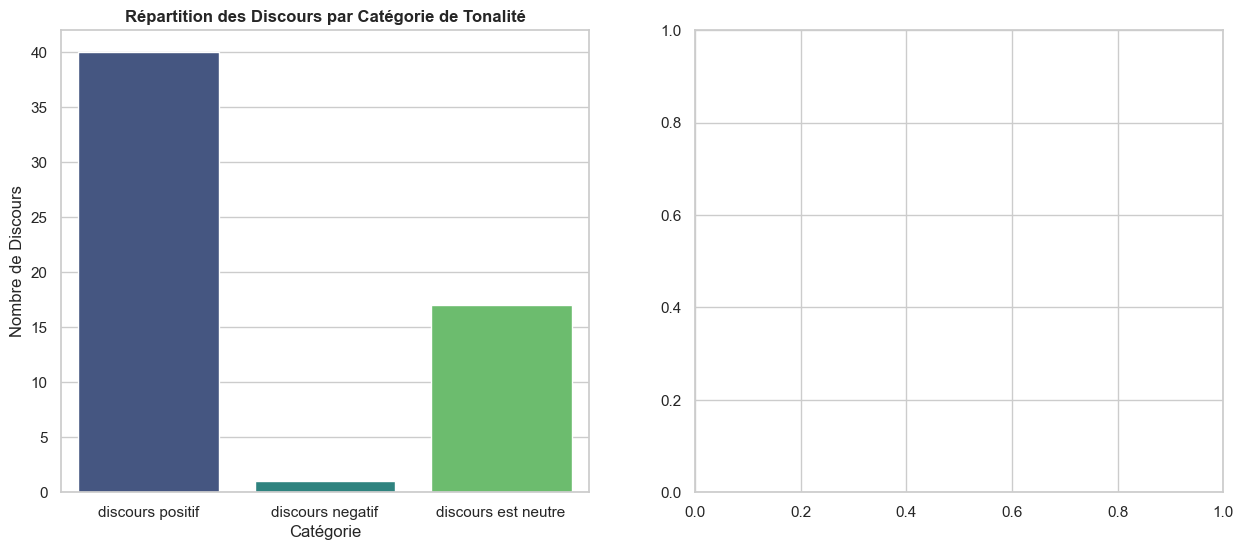

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed/inaug_speeches_nettoye_tonetsent.csv', encoding='latin1')

# Configuration du style des graphiques
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Diagramme en barres pour la Tonalité (si vous avez créé une colonne catégorielle)
if 'tonalite' in df.columns:
    sns.countplot(data=df, x='tonalite', ax=axes[0], palette='viridis', hue='tonalite', legend=False)
    axes[0].set_title("Répartition des Discours par Catégorie de Tonalité", fontsize=12, fontweight='bold')
    axes[0].set_xlabel("Catégorie")
    axes[0].set_ylabel("Nombre de Discours")

